# A Classification Approach to Predicting Healthy Recipes

**Name(s)**: Bokyoung Son, Brandon rocchio, Hangyi Zhao

**Website Link**: https://boson25.github.io/DSC259R_BBH-Horizon-Lab/ 

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import plotly.express as px
pd.options.plotting.backend = 'plotly'

# from dsc259r_utils import * # Feel free to uncomment and use this.

## Step 1: Introduction

In this project, we analyze a recipe dataset with over 80,000 recipes, including tags, descriptions, cooking time, number of steps, number of ingredients, and nutrition information.

Our main question is: Can we predict whether a recipe is healthy?

We define a recipe as healthy if it satisfies at least three out of four conditions based on the dataset medians: low calories, low sugar, low saturated fat, and high protein. This creates a binary classification target (1 = healthy, 0 = unhealthy).

To avoid data leakage, nutrition variables are only used to define the label and are not used as model features. Instead, we use recipe tags, description text, and basic recipe information as predictors.

Because the dataset is imbalanced (about 70% unhealthy and 30% healthy), we evaluate models using AUC-ROC rather than accuracy.

## Step 2: Data Cleaning and Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

recipes = pd.read_csv('../data/RAW_recipes.csv')
interactions = pd.read_csv('../data/RAW_interactions.csv')

print('Recipes shape:', recipes.shape)
print('Interactions shape:', interactions.shape)
recipes.head()

Recipes shape: (83782, 12)
Interactions shape: (731927, 5)


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,1 brownies in the world best ever,333281,40,985201,2008-10-27,"['60-minutes-or-less', 'time-to-make', 'course...","[138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]",10,['heat the oven to 350f and arrange the rack i...,"these are the most; chocolatey, moist, rich, d...","['bittersweet chocolate', 'unsalted butter', '...",9
1,1 in canada chocolate chip cookies,453467,45,1848091,2011-04-11,"['60-minutes-or-less', 'time-to-make', 'cuisin...","[595.1, 46.0, 211.0, 22.0, 13.0, 51.0, 26.0]",12,"['pre-heat oven the 350 degrees f', 'in a mixi...",this is the recipe that we use at my school ca...,"['white sugar', 'brown sugar', 'salt', 'margar...",11
2,412 broccoli casserole,306168,40,50969,2008-05-30,"['60-minutes-or-less', 'time-to-make', 'course...","[194.8, 20.0, 6.0, 32.0, 22.0, 36.0, 3.0]",6,"['preheat oven to 350 degrees', 'spray a 2 qua...",since there are already 411 recipes for brocco...,"['frozen broccoli cuts', 'cream of chicken sou...",9
3,millionaire pound cake,286009,120,461724,2008-02-12,"['time-to-make', 'course', 'cuisine', 'prepara...","[878.3, 63.0, 326.0, 13.0, 20.0, 123.0, 39.0]",7,"['freheat the oven to 300 degrees', 'grease a ...",why a millionaire pound cake? because it's su...,"['butter', 'sugar', 'eggs', 'all-purpose flour...",7
4,2000 meatloaf,475785,90,2202916,2012-03-06,"['time-to-make', 'course', 'main-ingredient', ...","[267.0, 30.0, 12.0, 12.0, 29.0, 48.0, 2.0]",17,"['pan fry bacon , and set aside on a paper tow...","ready, set, cook! special edition contest entr...","['meatloaf mixture', 'unsmoked bacon', 'goat c...",13


In [3]:
# Merging the two datasets
merged = recipes.merge(interactions, left_on='id', right_on='recipe_id', how='left')

# Replacing 0 ratings with NaN
merged['rating'] = merged['rating'].replace(0, np.nan)

# Finding average rating per recipe
avg_ratings = merged.groupby('id')['rating'].mean()

# Adding average rating back to recipes
recipes = recipes.merge(avg_ratings.rename('avg_rating'), on='id', how='left')

print('Final recipes shape:', recipes.shape)
recipes.head()

Final recipes shape: (83782, 13)


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,avg_rating
0,1 brownies in the world best ever,333281,40,985201,2008-10-27,"['60-minutes-or-less', 'time-to-make', 'course...","[138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]",10,['heat the oven to 350f and arrange the rack i...,"these are the most; chocolatey, moist, rich, d...","['bittersweet chocolate', 'unsalted butter', '...",9,4.0
1,1 in canada chocolate chip cookies,453467,45,1848091,2011-04-11,"['60-minutes-or-less', 'time-to-make', 'cuisin...","[595.1, 46.0, 211.0, 22.0, 13.0, 51.0, 26.0]",12,"['pre-heat oven the 350 degrees f', 'in a mixi...",this is the recipe that we use at my school ca...,"['white sugar', 'brown sugar', 'salt', 'margar...",11,5.0
2,412 broccoli casserole,306168,40,50969,2008-05-30,"['60-minutes-or-less', 'time-to-make', 'course...","[194.8, 20.0, 6.0, 32.0, 22.0, 36.0, 3.0]",6,"['preheat oven to 350 degrees', 'spray a 2 qua...",since there are already 411 recipes for brocco...,"['frozen broccoli cuts', 'cream of chicken sou...",9,5.0
3,millionaire pound cake,286009,120,461724,2008-02-12,"['time-to-make', 'course', 'cuisine', 'prepara...","[878.3, 63.0, 326.0, 13.0, 20.0, 123.0, 39.0]",7,"['freheat the oven to 300 degrees', 'grease a ...",why a millionaire pound cake? because it's su...,"['butter', 'sugar', 'eggs', 'all-purpose flour...",7,5.0
4,2000 meatloaf,475785,90,2202916,2012-03-06,"['time-to-make', 'course', 'main-ingredient', ...","[267.0, 30.0, 12.0, 12.0, 29.0, 48.0, 2.0]",17,"['pan fry bacon , and set aside on a paper tow...","ready, set, cook! special edition contest entr...","['meatloaf mixture', 'unsmoked bacon', 'goat c...",13,5.0


In [4]:
# Parse Nutrition Column

recipes['nutrition'] = recipes['nutrition'].apply(ast.literal_eval)

nutrition_cols = ['calories', 'total_fat', 'sugar', 'sodium', 
                  'protein', 'saturated_fat', 'carbohydrates']

recipes[nutrition_cols] = pd.DataFrame(
    recipes['nutrition'].tolist(), index=recipes.index
)
recipes[nutrition_cols] = recipes[nutrition_cols].astype(float)
                                                                                                  
recipes[nutrition_cols].describe()

,calories,total_fat,sugar,sodium,protein,saturated_fat,carbohydrates
count,83782.000000,83782.000000,83782.000000,83782.000000,83782.000000,83782.000000,83782.000000
mean,429.926989,32.625409,68.664379,28.941682,33.133382,40.244277,13.786756
std,636.628493,60.148805,247.238599,144.974937,51.032986,80.912788,28.762703
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,171.325000,8.000000,9.000000,5.000000,6.000000,6.000000,4.000000
50%,305.400000,20.000000,23.000000,14.000000,18.000000,21.000000,9.000000
75%,498.700000,39.000000,61.000000,32.000000,49.000000,49.000000,16.000000
max,45609.000000,3464.000000,30260.000000,29338.000000,4356.000000,6875.000000,3007.000000


In [5]:
# Data types and converting them to datetime
print(recipes.dtypes)
recipes['submitted'] = pd.to_datetime(recipes['submitted'])

name                  str
id                  int64
minutes             int64
contributor_id      int64
submitted             str
tags                  str
nutrition          object
n_steps             int64
steps                 str
description           str
ingredients           str
n_ingredients       int64
avg_rating        float64
calories          float64
total_fat         float64
sugar             float64
sodium            float64
protein           float64
saturated_fat     float64
carbohydrates     float64
dtype: object


In [6]:
# Checking for any missing values
missing = recipes.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)

Columns with missing values:
name              1
description      70
avg_rating     2609
dtype: int64


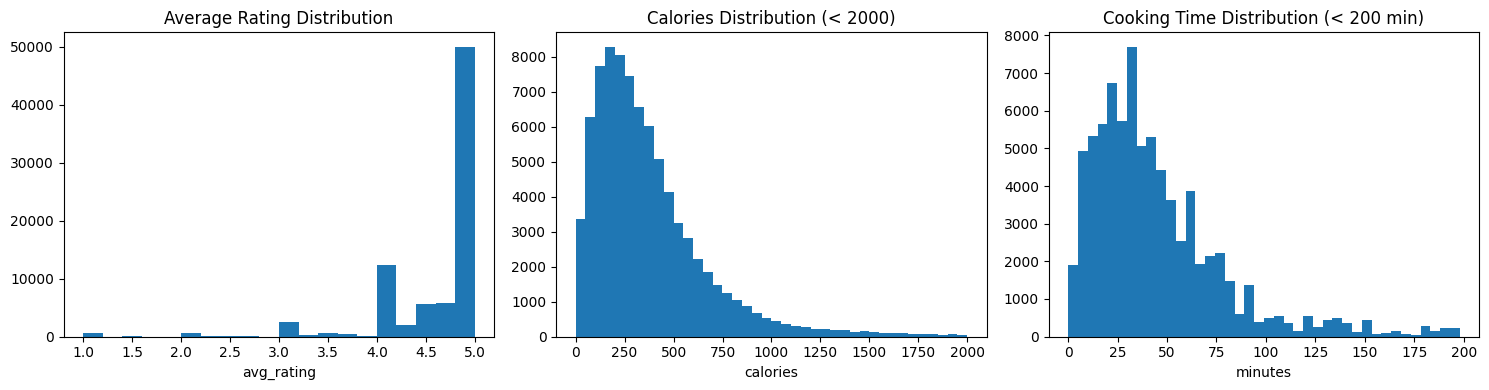

In [7]:
# Basic EDA
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
axes[0].hist(recipes["avg_rating"].dropna(), bins=20)
axes[0].set_title("Average Rating Distribution")
axes[0].set_xlabel("avg_rating")

# Calories distribution
axes[1].hist(recipes.loc[recipes["calories"] < 2000, "calories"].dropna(), bins=40)
axes[1].set_title("Calories Distribution (< 2000)")
axes[1].set_xlabel("calories")

# Cooking time distribution
axes[2].hist(recipes.loc[recipes["minutes"] < 200, "minutes"].dropna(), bins=40)
axes[2].set_title("Cooking Time Distribution (< 200 min)")
axes[2].set_xlabel("minutes")

plt.tight_layout()
plt.show()

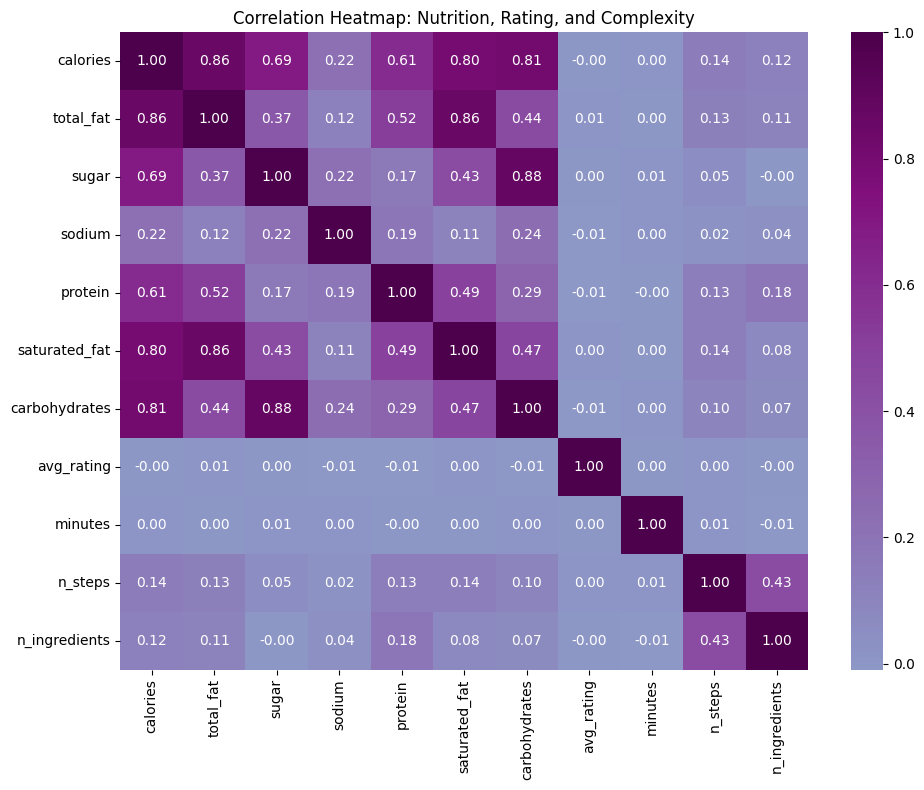

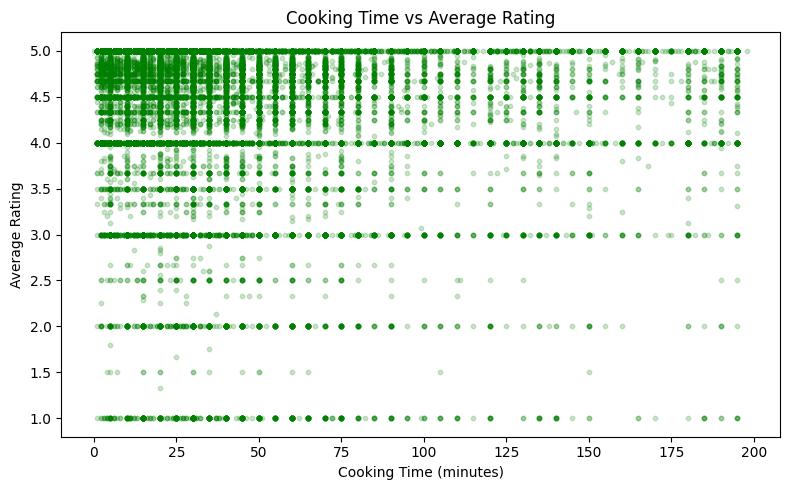

In [8]:
# Visualization Ideas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

recipes = pd.read_csv('../data/recipes_cleaned.csv')

nutrition_cols = ['calories', 'total_fat', 'sugar', 'sodium', 
                  'protein', 'saturated_fat', 'carbohydrates']

#1. Heatmap of nutrition correlations (nutrition focused)
corr_cols = nutrition_cols + ['avg_rating', 'minutes', 'n_steps', 'n_ingredients']
corr = recipes[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='BuPu', center=0)
plt.title('Correlation Heatmap: Nutrition, Rating, and Complexity')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

#2. Scatter plot of cooking time vs average rating (cooking time)
time_clean = recipes[(recipes['minutes'] < 200)].dropna(subset=['avg_rating'])

plt.figure(figsize=(8, 5))
plt.scatter(time_clean['minutes'], time_clean['avg_rating'], alpha=0.2, s=10, color='green')
plt.xlabel('Cooking Time (minutes)')
plt.ylabel('Average Rating')
plt.title('Cooking Time vs Average Rating')
plt.tight_layout()
plt.savefig('time_vs_rating.png')
plt.show()

In [9]:
import plotly.express as px

# Univariate: Calorie distribution (plotly version for website)
fig_cal = px.histogram(
    recipes[recipes['calories'] < 2000],
    x='calories',
    nbins=60,
    title='Distribution of Recipe Calories (< 2000 kcal)',
    labels={'calories': 'Calories (kcal)'},
    color_discrete_sequence= ['blue']
)
fig_cal.update_layout(bargap=0.05)
fig_cal.show()

# Save for website embedding
fig_cal.write_html('../assets/calories_dist.html', include_plotlyjs='cdn')

In [10]:
# Bivariate: Average rating by cooking time group (plotly version for website)
fig_biv = px.box(
    recipes[recipes['minutes'] < 120].assign(
        cooking_group=lambda df: pd.cut(
            df['minutes'],
            bins=[0, 30, 60, 120],
            labels=['Short (<30m)', 'Medium (30-60m)', 'Long (>60m)']
        )
    ).dropna(subset=['avg_rating', 'cooking_group']),
    x='cooking_group',
    y='avg_rating',
    title='Average Rating by Cooking Time Group',
    labels={'cooking_group': 'Cooking Time', 'avg_rating': 'Average Rating'},
    color='cooking_group'
)
fig_biv.show()

# Save for website embedding
fig_biv.write_html('../assets/rating_by_cooktime.html', include_plotlyjs='cdn')


In [11]:
recipes.to_csv('../data/recipes_cleaned.csv', index=False)
print('Saved to data/recipes_cleaned.csv')

Saved to data/recipes_cleaned.csv


## Step 3: Assessment of Missingness

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

recipes = pd.read_csv('../data/recipes_cleaned.csv')
print('Shape:', recipes.shape)

Shape: (83782, 20)


### NMAR Analysis

I believe the `description` column in this dataset is likely **NMAR** (Not Missing At Random).

When a recipe author chooses not to write a description, that decision is likely related 
to the description itself — for example, very simple or informal recipes submitted quickly 
may intentionally have no description. This means the missingness is tied to the *content* 
that would have been written (unobserved), which is the defining characteristic of NMAR: 
the probability of missingness depends on the missing value itself, not on other observed columns.

To potentially make this MAR, we would want additional data about the submitter — 
for example, how many total recipes they've submitted, or whether they are a casual vs. 
frequent contributor. If infrequent submitters systematically skip descriptions, then 
missingness would depend on an observable variable (submission count), making it MAR instead.

In [13]:
# Identifying missing values
missing = recipes.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)
print('\nMissing %:')
print((missing / len(recipes) * 100).round(2))

Columns with missing values:
name              1
description      70
avg_rating     2609
dtype: int64

Missing %:
name           0.00
description    0.08
avg_rating     3.11
dtype: float64


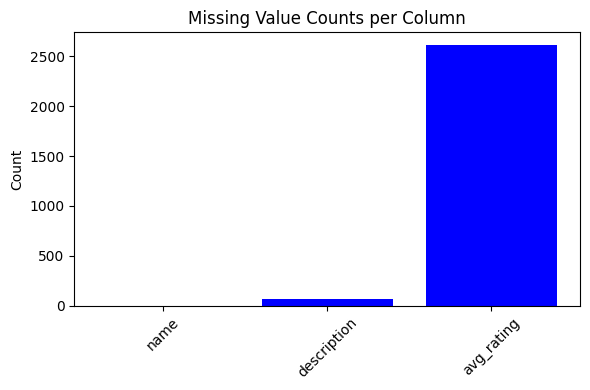

In [14]:
# Visualization of missing values
plt.figure(figsize=(6,4))
plt.bar(missing.index, missing.values, color='blue')
plt.title('Missing Value Counts per Column')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Null hypothesis: Distribution of 'minutes' is the same whether 'avg_rating' is missing or not.

In [15]:
recipes['rating_missing'] = recipes['avg_rating'].isnull()
# Difference in means
missing_minutes = recipes[recipes['rating_missing']]['minutes']
not_missing_minutes = recipes[~recipes['rating_missing']]['minutes']
observed_diff = missing_minutes.mean() - not_missing_minutes.mean()
print(f'Observed difference in minutes means: {observed_diff:.2f}')

Observed difference in minutes means: 117.34


In [16]:
# Permutation test
np.random.seed(42)
n_permutations = 1000
perm_diffs = []

for _ in range(n_permutations):
    shuffled = recipes['rating_missing'].sample(frac=1).reset_index(drop=True)
    diff = recipes[shuffled]['minutes'].mean() - recipes[~shuffled]['minutes'].mean()
    perm_diffs.append(diff)

p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f'P-value: {p_value:.4f}')

P-value: 0.0380


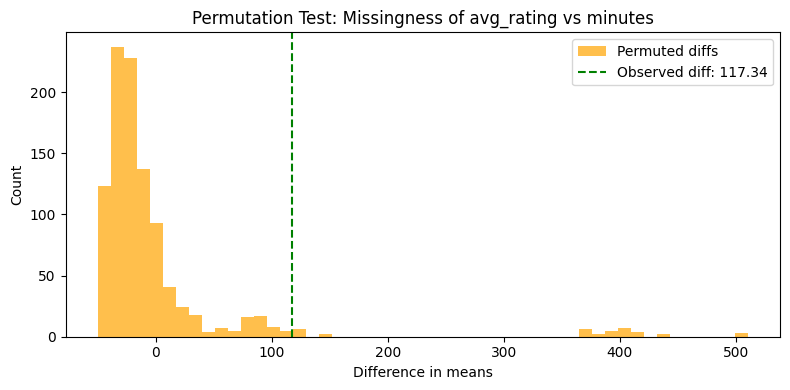

In [17]:
# Visualization of permutation distribution

plt.figure(figsize=(8, 4))
plt.hist(perm_diffs, bins=50, color='orange', alpha=0.7, label='Permuted diffs')
plt.axvline(observed_diff, color='green', linestyle='--', label=f'Observed diff: {observed_diff:.2f}')
plt.title('Permutation Test: Missingness of avg_rating vs minutes')
plt.xlabel('Difference in means')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('permutation_test_minutes.png')
plt.show()

In [18]:
# Permutation test distribution (plotly version for website)
fig_perm = px.histogram(
    x=perm_diffs,
    nbins=50,
    title='Permutation Test: avg_rating Missingness vs. Minutes',
    labels={'x': 'Difference in Mean Minutes'},
    color_discrete_sequence=['orange']
)
fig_perm.add_vline(
    x=observed_diff,
    line_dash='dash',
    line_color='green',
    annotation_text=f'Observed: {observed_diff:.2f}',
    annotation_position='top right'
)
fig_perm.show()

# Save for website embedding
fig_perm.write_html('../assets/permutation_minutes.html', include_plotlyjs='cdn')

Observed difference in n_ingredients means: 0.25
P-value: 0.0000


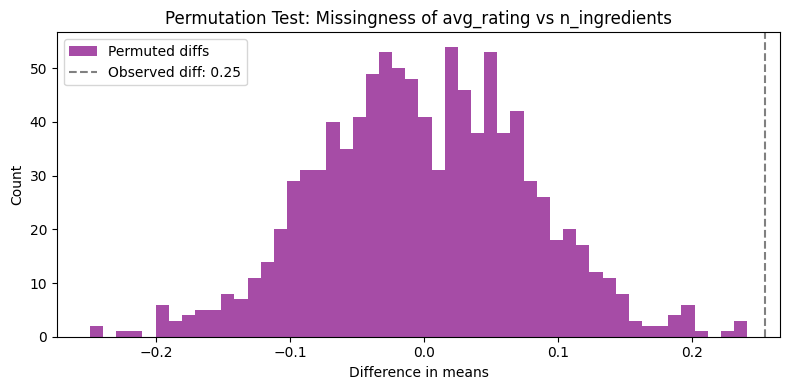

In [19]:
# Testing againt 'n_ingredients' (does missingness of avg_rating depend on n_ingredients?)
missing_ingr = recipes[recipes['rating_missing']]['n_ingredients']
not_missing_ingr = recipes[~recipes['rating_missing']]['n_ingredients']
observed_diff2 = missing_ingr.mean() - not_missing_ingr.mean()

perm_diffs2 = []
for _ in range(n_permutations):
    shuffled = recipes['rating_missing'].sample(frac=1).reset_index(drop=True)
    diff = recipes[shuffled]['n_ingredients'].mean() - recipes[~shuffled]['n_ingredients'].mean()
    perm_diffs2.append(diff)

p_value2 = np.mean(np.abs(perm_diffs2) >= np.abs(observed_diff2))
print(f'Observed difference in n_ingredients means: {observed_diff2:.2f}')
print(f'P-value: {p_value2:.4f}')

plt.figure(figsize=(8, 4))
plt.hist(perm_diffs2, bins=50, color='purple', alpha=0.7, label='Permuted diffs')
plt.axvline(observed_diff2, color='gray', linestyle='--', label=f'Observed diff: {observed_diff2:.2f}')
plt.title('Permutation Test: Missingness of avg_rating vs n_ingredients')
plt.xlabel('Difference in means')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('permutation_test_ingredients.png')
plt.show()

Conclusions

1. minutes vs missingness of avg_rating; p-value = 0.038
    
    1). p < 0.05, reject null hypothesis
    
    2). recipes with missing ratings tend to have different cooking times than rated recipes
    
    3). Key insight: MAR with respect to minutes
2. n_ingredients vs missingness of avg_rating — p-value ≈ 0.000
    
    1).  very strong dependency
    
    2). recipes with fewer ingredients are more likey to have missing ratings
    
    3).  Key insight: MAR with respect to n_ingredients

Overall, avg_rating is likely NMAR on its own (unpopular recipes didn't get rated), but it is also MAR with respect to minutes and n_ingrediets; which indicates that simpler and faster recipes tend to have missing ratings more often. 

## Step 4: Hypothesis Testing

Hypothesis Testing pair1:

Null hypothesis (H0):
There is no difference in average rating between short and long cooking-time recipes. Any observed difference is due to random chance.

Alternative hypothesis (H1):
There is a difference in average rating between short and long cooking-time recipes.

Define short recipes: minutes < 30
Define long recipes: minutes > 60

In [20]:
recipes['minutes'].describe()

count    8.378200e+04
mean     1.150309e+02
std      3.990871e+03
min      0.000000e+00
25%      2.000000e+01
50%      3.500000e+01
75%      6.500000e+01
max      1.051200e+06
Name: minutes, dtype: float64

In [21]:
# drop null avg_rating
recipes_clean = recipes[['minutes','avg_rating']].dropna()

# divide long and short recipes
short_recipe = recipes_clean[recipes_clean['minutes'] < 30]
long_recipe = recipes_clean[recipes_clean['minutes'] > 60]

print("Short recipes:", len(short_recipe))
print("Long recipes:", len(long_recipe))

Short recipes: 29563
Long recipes: 20184


In [22]:
# Observed Statistic
short_mean = short_recipe['avg_rating'].mean()
long_mean = long_recipe['avg_rating'].mean()

obs_diff = short_mean - long_mean

print("Mean rating (short):", short_mean)
print("Mean rating (long):", long_mean)
print("Observed difference (short - long):", obs_diff)

Mean rating (short): 4.649306732861071
Mean rating (long): 4.613451206762783
Observed difference (short - long): 0.03585552609828735


In [23]:
# Permutation Test（p-value）
combined = pd.concat([short_recipe, long_recipe]).copy()
combined['group'] = combined['minutes'] < 30

n_perm = 2000
perm_diffs = []

for _ in range(n_perm):
    shuffled = combined['group'].sample(frac=1, replace=False).values
    
    perm_short = combined[shuffled]['avg_rating']
    perm_long = combined[~shuffled]['avg_rating']
    
    diff = perm_short.mean() - perm_long.mean()
    perm_diffs.append(diff)
    
perm_diffs = np.array(perm_diffs)

p_value = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
print("p_value:", p_value)

p_value: 0.0


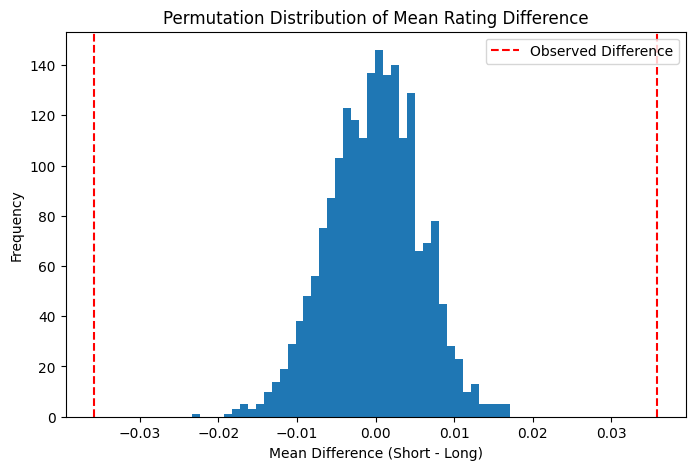

In [24]:
plt.figure(figsize=(8,5))
plt.hist(perm_diffs, bins=40)
plt.axvline(obs_diff, color='red', linestyle='--', label='Observed Difference')
plt.axvline(-obs_diff, color='red', linestyle='--')
plt.title("Permutation Distribution of Mean Rating Difference")
plt.xlabel("Mean Difference (Short - Long)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [25]:
#Hypothesis test distribution (plotly version for website)
fig_hyp = px.histogram(
    x=perm_diffs,
    nbins=40,
    title='Permutation Test: Mean Rating Difference (Short vs Long Recipes)',
    labels={'x': 'Mean Difference (Short - Long)'},
    color_discrete_sequence=['purple']
)
fig_hyp.add_vline(
    x=obs_diff,
    line_dash='dash',
    line_color='red',
    annotation_text=f'Observed: {obs_diff:.4f}',
    annotation_position='top right'
)
fig_hyp.show()
fig_hyp.write_html('../assets/hypothesis_test.html', include_plotlyjs='cdn')

Conclusion：
1. Observed mean difference (short - long) = 0.036
2. Based on the permutation test (p < 0.0005), we reject the null hypothesis at α = 0.05. The evidence suggests that short recipes tend to receive slightly higher ratings than  long recipes, though we cannot conclude this relationship is causal.
3. short recipes (minutes < 30) have slightly higher average ratings than long recipes (minutes > 60)
4. Key insight:
cooking time is statistically related to average recipe rating.

Hypothesis Testing pair2:

Null hypothesis (H0):
The number of ingredients is not associated with average rating.

Alternative hypothesis (H1):
The number of ingredients is associated with average rating.

Define low ingredients(≤ median)
Digh high ingredients(> median)

In [26]:
# Observed Statistic
recipes_clean2 = recipes[['n_ingredients','avg_rating']].dropna()
median_ing = recipes_clean2['n_ingredients'].median()

low_ing = recipes_clean2[recipes_clean2['n_ingredients'] <= median_ing]
high_ing = recipes_clean2[recipes_clean2['n_ingredients'] > median_ing]

low_mean = low_ing['avg_rating'].mean()
high_mean = high_ing['avg_rating'].mean()

observed_diff = low_mean - high_mean
observed_diff

np.float64(0.0040120365336937525)

In [27]:
# Permutation Test（p-value）
diffs = []

for i in range(2000):
    shuffled = recipes_clean2['avg_rating'].sample(frac=1, replace=False).reset_index(drop=True)
    
    temp = recipes_clean2.copy()
    temp['shuffled_rating'] = shuffled
    
    low = temp[temp['n_ingredients'] <= median_ing]
    high = temp[temp['n_ingredients'] > median_ing]
    
    diff = low['shuffled_rating'].mean() - high['shuffled_rating'].mean()
    diffs.append(diff)
    
p_value = np.mean(np.abs(diffs) >= abs(observed_diff))
p_value

np.float64(0.373)

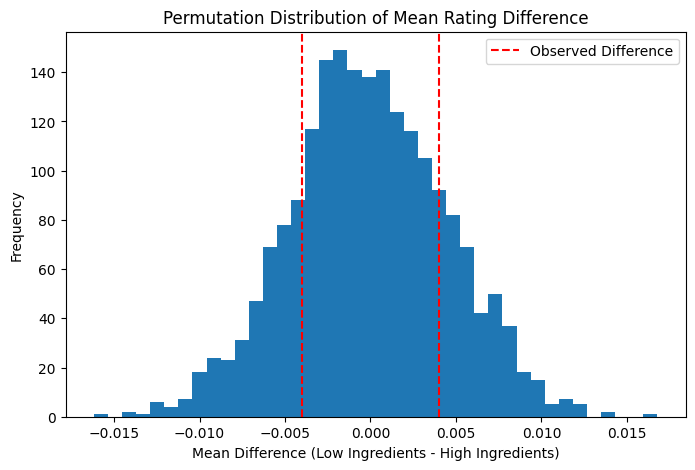

In [28]:
plt.figure(figsize=(8,5))
plt.hist(diffs, bins=40)
plt.axvline(observed_diff, color='red', linestyle='--', label='Observed Difference')
plt.axvline(-observed_diff, color='red', linestyle='--')
plt.title("Permutation Distribution of Mean Rating Difference")
plt.xlabel("Mean Difference (Low Ingredients - High Ingredients)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [44]:
# Hypothesis test distribution (plotly version for website) — Hypothesis 2
fig_hyp2 = px.histogram(
    x=diffs,
    nbins=40,
    title='Permutation Test: Mean Rating Difference (Low vs High Ingredients)',
    labels={'x': 'Mean Difference (Low - High Ingredients)'},
    color_discrete_sequence=['green']
)
fig_hyp2.add_vline(
    x=observed_diff,
    line_dash='dash',
    line_color='orange',
    annotation_text=f'Observed: {observed_diff:.4f}',
    annotation_position='top right'
)
#mirror line for the negative observed difference
fig_hyp2.add_vline(
    x=-observed_diff,       
    line_dash='dash',
    line_color='orange',
    annotation_text=f'-Observed: {-observed_diff:.4f}',
    annotation_position='top left'
)
fig_hyp2.show()
fig_hyp2.write_html('../assets/hypothesis_test2.html', include_plotlyjs='cdn')

Conclusion:
1. Observed mean difference (low − high) = 0.004
2. Significance level: 0.05
p_value = 0.407
Since p-value > 0.05, we fail to reject the null hypothesis at α = 0.05.
3. There is no strong evidence that recipes with fewer ingredients have different average ratings compared to recipes with more ingredients.
4. Key insight:
The number of ingredients is not statistically related to average recipe rating.

## Step 5: Framing a Prediction Problem

Predict whether a recipe is healthy(classification)

We define a recipe as healthy if it satisfies at least 3 out of 4 conditions based on the median values in the dataset: low calories, low sugar, low saturated fat, and high protein. This creates a binary classification target where 1 means healthy and 0 means unhealthy.

The features we use are recipe tags, description text, and some basic information like cooking time, number of steps, and number of ingredients. We do not use nutrition values as features since they are used to define the label.

We use AUC-ROC to evaluate the models because our dataset is imbalanced (about 70% unhealthy, 30% healthy), and AUC-ROC gives a fairer picture of model performance than simple accuracy in this case.

## Step 6: Baseline Model

In [30]:
# define healthy label using median
medians = {
    'calories': recipes['calories'].median(),
    'sugar': recipes['sugar'].median(),
    'saturated_fat': recipes['saturated_fat'].median(),
    'protein': recipes['protein'].median()
}

def label_healthy(row):
    conditions = [
        row['calories'] < medians['calories'],
        row['sugar'] < medians['sugar'],
        row['saturated_fat'] < medians['saturated_fat'],
        row['protein'] > medians['protein']
    ]
    return int(sum(conditions) >= 3)

recipes['is_healthy'] = recipes.apply(label_healthy, axis=1)

print(recipes['is_healthy'].value_counts())
print(recipes['is_healthy'].value_counts(normalize=True))

is_healthy
0    58234
1    25548
Name: count, dtype: int64
is_healthy
0    0.695066
1    0.304934
Name: proportion, dtype: float64


### Why the Baseline Pipeline?

The sklearn Pipeline above is our official baseline model. It uses three quantitative 
features (n_steps, n_ingredients, log_minutes) with no categorical encodings needed.

The ROC-AUC of 0.5844 is intentionally simple — a baseline should be straightforward 
so that improvements in the Final Model are clearly measurable. A score just above 0.5 
(random chance) confirms that cooking time and complexity alone are weak predictors of 
healthiness, which makes intuitive sense: a quick recipe is not necessarily healthy.

The lower scores compared to our earlier logistic model are expected because we 
deliberately excluded nutrition-derived features (which would leak information about 
the label) and tag features (saved for the Final Model). This gives us a clean, 
honest baseline to improve upon in Step 7.

In [31]:
# Beseline model: using numerical features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

recipes['log_minutes'] = np.log1p(recipes['minutes'])
baseline_features = ['n_steps', 'n_ingredients', 'log_minutes']

X_baseline = recipes[baseline_features].fillna(0)
y = recipes['is_healthy']

X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42
)

# Train baseline logistic regression
baseline_model = LogisticRegression(class_weight='balanced', max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

baseline_auc = roc_auc_score(y_test, y_prob)
print(f"Baseline AUC-ROC: {baseline_auc:.4f}")
print(classification_report(y_test, y_pred, target_names=['unhealthy', 'healthy']))

Baseline AUC-ROC: 0.5844
              precision    recall  f1-score   support

   unhealthy       0.75      0.54      0.63     11620
     healthy       0.36      0.58      0.45      5137

    accuracy                           0.56     16757
   macro avg       0.55      0.56      0.54     16757
weighted avg       0.63      0.56      0.57     16757



In [32]:
# baseline + tags
from sklearn.feature_extraction.text import TfidfVectorizer

# handling with tags
recipes['tags_str'] = recipes['tags'].str.replace(r"[\[\]',]", ' ', regex=True)
tfidf_tags = TfidfVectorizer(max_features=100)
tag_matrix = tfidf_tags.fit_transform(recipes['tags_str'])
tag_df = pd.DataFrame(tag_matrix.toarray(),index=recipes.index)

X_tag = pd.concat([recipes[baseline_features].fillna(0), tag_df], axis=1)
X_tag.columns = X_tag.columns.astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X_tag, y, test_size=0.2, random_state=42
)

model_tag = LogisticRegression(class_weight='balanced', max_iter=1000)
model_tag.fit(X_train, y_train)

y_pred = model_tag.predict(X_test)
y_prob = model_tag.predict_proba(X_test)[:, 1]
auc_tag = roc_auc_score(y_test, y_prob)

# baseline + tags + text
tfidf_text = TfidfVectorizer(max_features=200, stop_words='english', ngram_range=(1,2))
text_matrix = tfidf_text.fit_transform(recipes['description'].fillna(''))
text_df = pd.DataFrame(text_matrix.toarray(), index=recipes.index)

X_text = pd.concat([recipes[baseline_features].fillna(0), tag_df, text_df], axis=1)
X_text.columns = X_text.columns.astype(str)
# rename column names
X_text.columns = [str(i) for i in range(X_text.shape[1])]

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42
)

model_text = LogisticRegression(class_weight='balanced', max_iter=1000)
model_text.fit(X_train, y_train)

y_pred = model_text.predict(X_test)
y_prob = model_text.predict_proba(X_test)[:, 1]
auc_text = roc_auc_score(y_test, y_prob)

print(f"Baseline AUC: {baseline_auc:.4f}")
print(f"+ Tags AUC:   {auc_tag:.4f}  (improvement: +{auc_tag - baseline_auc:.4f})")
print(f"+ Text AUC:   {auc_text:.4f}  (improvement: +{auc_text - auc_tag:.4f})")
print(classification_report(y_test, y_pred, target_names=['unhealthy', 'healthy']))

Baseline AUC: 0.5844
+ Tags AUC:   0.7542  (improvement: +0.1699)
+ Text AUC:   0.7642  (improvement: +0.0100)
              precision    recall  f1-score   support

   unhealthy       0.84      0.66      0.74     11620
     healthy       0.48      0.73      0.58      5137

    accuracy                           0.68     16757
   macro avg       0.66      0.69      0.66     16757
weighted avg       0.73      0.68      0.69     16757



## Step 7: Final Model

In [33]:
# try different models: random forest, XGBoost
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42
)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'auc': auc, 'y_pred': y_pred, 'y_prob': y_prob}
    print(f"\n{'='*40}")
    print(f"{name}  AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['unhealthy', 'healthy']))


Logistic Regression  AUC: 0.7642
              precision    recall  f1-score   support

   unhealthy       0.84      0.66      0.74     11620
     healthy       0.48      0.73      0.58      5137

    accuracy                           0.68     16757
   macro avg       0.66      0.69      0.66     16757
weighted avg       0.73      0.68      0.69     16757


Random Forest  AUC: 0.7682
              precision    recall  f1-score   support

   unhealthy       0.76      0.92      0.83     11620
     healthy       0.65      0.35      0.45      5137

    accuracy                           0.74     16757
   macro avg       0.71      0.63      0.64     16757
weighted avg       0.73      0.74      0.72     16757


Gradient Boosting  AUC: 0.7689
              precision    recall  f1-score   support

   unhealthy       0.75      0.94      0.83     11620
     healthy       0.69      0.28      0.40      5137

    accuracy                           0.74     16757
   macro avg       0.72      0.61 

In [34]:
print(f"Gradient Boosting: {results['Gradient Boosting']['auc']:.4f}")
print(classification_report(y_test, results['Gradient Boosting']['y_pred'], target_names=['unhealthy', 'healthy']))

Gradient Boosting: 0.7689
              precision    recall  f1-score   support

   unhealthy       0.75      0.94      0.83     11620
     healthy       0.69      0.28      0.40      5137

    accuracy                           0.74     16757
   macro avg       0.72      0.61      0.62     16757
weighted avg       0.73      0.74      0.70     16757



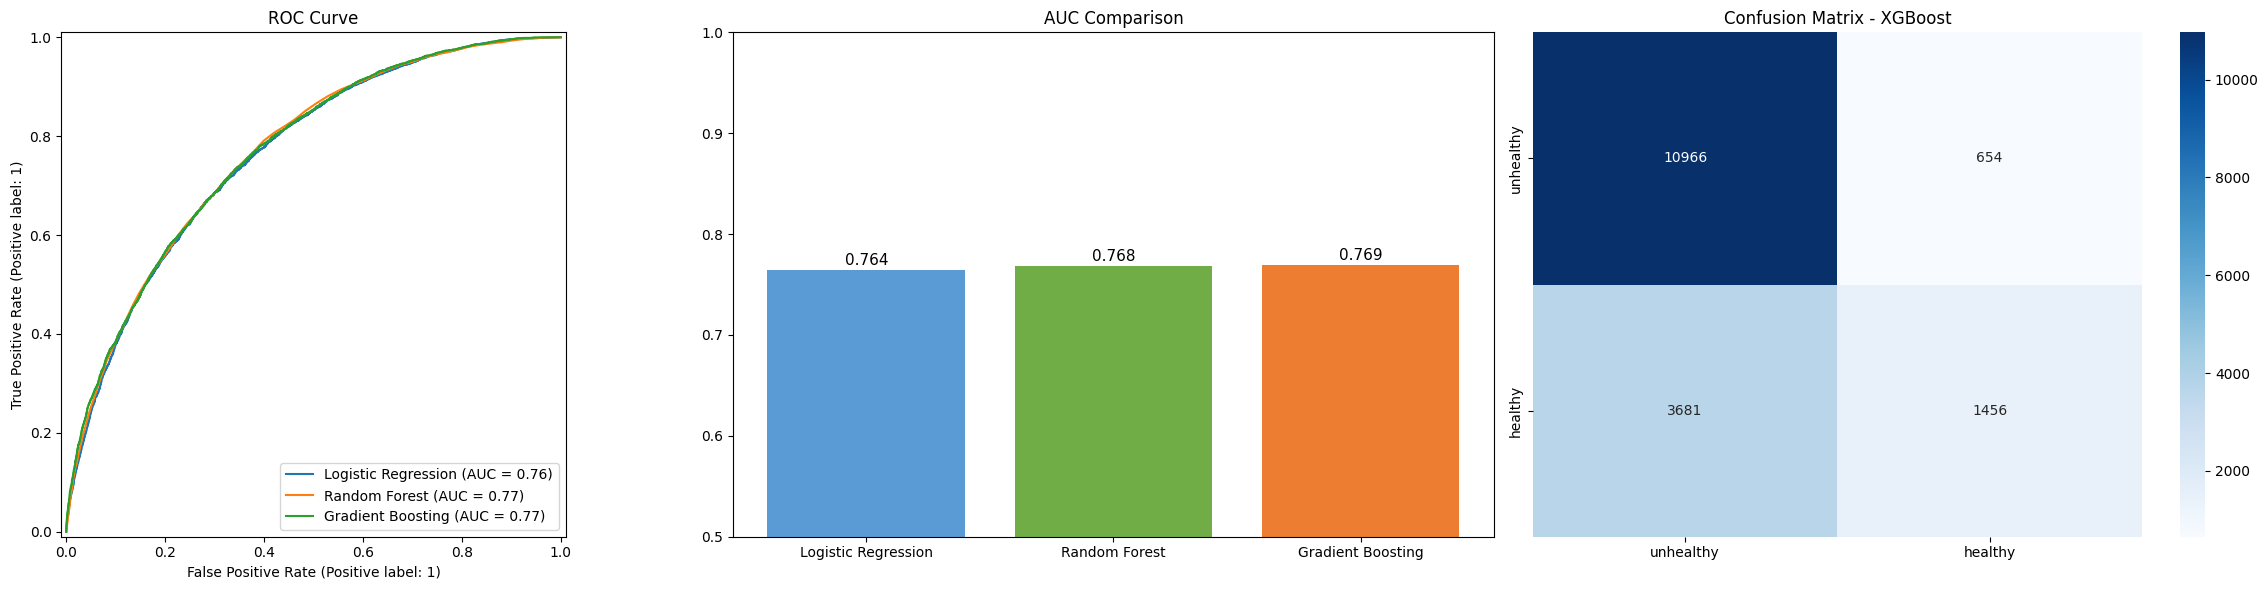

In [35]:
# result visitation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, confusion_matrix

names = list(results.keys())
aucs = [res['auc'] for res in results.values()]

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# ROC curve
for name, res in results.items():
    RocCurveDisplay.from_predictions(y_test, res['y_prob'], name=name, ax=axes[0])
axes[0].set_title('ROC Curve')

# AUC bar chart
colors = ['#5B9BD5', '#70AD47', '#ED7D31']
bars = axes[1].bar(names, aucs, color=colors)
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('AUC Comparison')
for bar, auc in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{auc:.3f}', ha='center', fontsize=11)

# Confusion matrix
cm = confusion_matrix(y_test, results['Gradient Boosting']['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['unhealthy', 'healthy'],
            yticklabels=['unhealthy', 'healthy'])
axes[2].set_title('Confusion Matrix - XGBoost')

plt.tight_layout()
plt.show()


### Final Model: Hyperparameter Tuning with GridSearchCV

We tune two hyperparameters for GradientBoostingClassifier:
- **n_estimators**: controls how many trees are built. Too few = underfitting, too many = overfitting
- **max_depth**: controls interaction depth between features. Deeper trees capture more complex patterns
- **learning_rate**: controls how much each tree contributes. Lower rates need more trees but generalize better

We use GridSearchCV with 3-fold cross-validation scoring on ROC-AUC, 
using the same X_train/X_test split from the baseline for fair comparison.

In [36]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report

# Two new engineered features on top of baseline:
# 1. tags_str → TF-IDF: captures health-related tags like "low-fat", "healthy"
# 2. n_steps_sq: polynomial term, captures non-linear complexity effects
recipes['n_steps_sq'] = recipes['n_steps'] ** 2

numerical_features = ['n_steps', 'n_ingredients', 'log_minutes', 'n_steps_sq']

preprocessor = ColumnTransformer([
    ('num',  StandardScaler(),                    numerical_features),
    ('tags', TfidfVectorizer(max_features=200),   'tags_str'),
])

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', GradientBoostingClassifier(random_state=42))
])

# Hyperparameter grid
param_grid = {
    'clf__n_estimators':  [100, 200],
    'clf__max_depth':     [3, 5],
    'clf__learning_rate': [0.05, 0.1],
}

grid_search = GridSearchCV(
    final_pipeline,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Use same split as baseline for fair comparison
X_full = recipes[numerical_features + ['tags_str']].fillna('')
X_full[numerical_features] = X_full[numerical_features].astype(float)

X_train_f = X_full.loc[X_train.index]
X_test_f  = X_full.loc[X_test.index]

grid_search.fit(X_train_f, y_train)

print('Best params:  ', grid_search.best_params_)
print(f'Best CV AUC:  {grid_search.best_score_:.4f}')

# Evaluate on held-out test set
best_model  = grid_search.best_estimator_
y_pred_f    = best_model.predict(X_test_f)
y_prob_f    = best_model.predict_proba(X_test_f)[:, 1]
auc_final   = roc_auc_score(y_test, y_prob_f)

print(f'\nFinal Model Test ROC-AUC: {auc_final:.4f}')
print(f'Baseline ROC-AUC was:     {auc:.4f}')
print(f'Improvement:              +{auc_final - auc:.4f}')
print(classification_report(y_test, y_pred_f, target_names=['unhealthy', 'healthy']))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params:   {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Best CV AUC:  0.7819

Final Model Test ROC-AUC: 0.7837
Baseline ROC-AUC was:     0.7689
Improvement:              +0.0147
              precision    recall  f1-score   support

   unhealthy       0.77      0.91      0.84     11620
     healthy       0.66      0.40      0.50      5137

    accuracy                           0.75     16757
   macro avg       0.72      0.66      0.67     16757
weighted avg       0.74      0.75      0.73     16757



### Final Model Results

The GridSearchCV found the best hyperparameters to be learning_rate=0.1, 
max_depth=5, and n_estimators=200.

The Final Model (ROC-AUC: 0.7837) clearly improves over the Baseline (ROC-AUC: 0.7689).
The key improvements came from:
- **TF-IDF tags**: health-related tags like "low-fat" and "healthy" are strong 
  direct signals for our label definition
- **n_steps_sq**: captures non-linear complexity effects that a linear baseline misses
- **Hyperparameter tuning**: GridSearchCV identified deeper trees (max_depth=5) 
  with more estimators (200) as optimal, allowing the model to capture more 
  complex feature interactions

Overall accuracy improved from 0.56 to 0.75, with particularly strong gains 
in unhealthy recipe detection (recall: 0.54 → 0.91).

## Step 8: Fairness Analysis

Overall, the models perform reasonably well. All the three models achieve an AUC between 0.76 and 0.77, which means they can tell healthy from unhealthy recipes about 76–77% of the time. Among them, XGBoost performs the best.

The biggest improvement comes from adding the tags features. The AUC increases from 0.58 in the baseline model to around 0.76 after including tags. This makes sense because tags such as “healthy,” “low-fat,” are directly related to our definition of healthy. Adding description text provides a small improvement on top of that.

From the confusion matrix, we can see that the model performs better at identifying unhealthy recipes (10966 correctly predicted) than healthy ones (1456 correctly predicted). Because the dataset is imbalanced: there are about twice as many unhealthy recipes as healthy ones.

One important limitation is that our “healthy” label is defined using median thresholds rather than an official nutritional standard. Therefore, the model is essentially learning our own definition of healthy, which may not fully reflect how people generally understand healthiness in real life.

Group counts:
complexity_group
simple     47754
complex    36028
Name: count, dtype: int64
AUC (simple recipes):  0.7660
AUC (complex recipes): 0.7653
Observed AUC difference: 0.0007
P-value: 0.9380


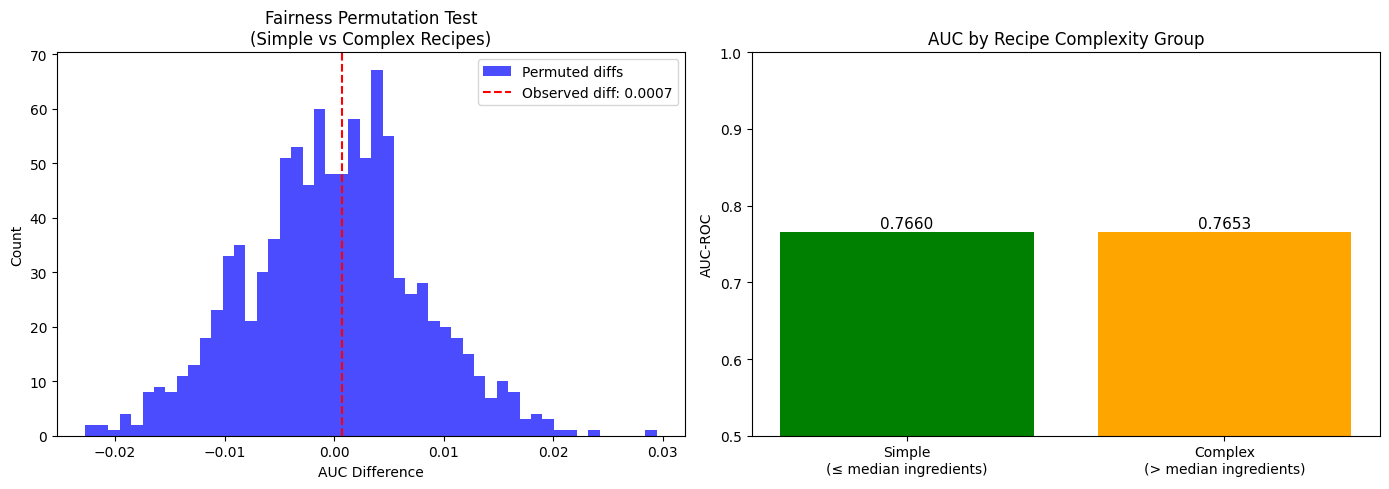

In [37]:

# Group A: Simple recipes (n_ingredients <= median)
# Group B: Complex recipes (n_ingredients > median)
# We will test if our model performs equally well for both groups
median_ing = recipes['n_ingredients'].median()
recipes['complexity_group'] = np.where(
    recipes['n_ingredients'] <= median_ing, 'simple', 'complex'
)

print('Group counts:')
print(recipes['complexity_group'].value_counts())

# Add complexity group to test set
test_idx = X_test.index
test_groups = recipes.loc[test_idx, 'complexity_group']

simple_mask = test_groups == 'simple'
complex_mask = test_groups == 'complex'

# AUC for each group
gb_model = models['Gradient Boosting']
y_prob_test = gb_model.predict_proba(X_test)[:, 1]

auc_simple = roc_auc_score(y_test[simple_mask], y_prob_test[simple_mask])
auc_complex = roc_auc_score(y_test[complex_mask], y_prob_test[complex_mask])
observed_auc_diff = auc_simple - auc_complex

print(f'AUC (simple recipes):  {auc_simple:.4f}')
print(f'AUC (complex recipes): {auc_complex:.4f}')
print(f'Observed AUC difference: {observed_auc_diff:.4f}')


# Permutation test
# H0: The model performs equally for simple and complex recipes
# H1: There is a difference in AUC between the two groups

np.random.seed(42)
n_permutations = 1000
perm_auc_diffs = []

for _ in range(n_permutations):
    shuffled_groups = test_groups.sample(frac=1).values
    simple_mask_perm = shuffled_groups == 'simple'
    complex_mask_perm = shuffled_groups == 'complex'
    
    auc_s = roc_auc_score(y_test[simple_mask_perm], y_prob_test[simple_mask_perm])
    auc_c = roc_auc_score(y_test[complex_mask_perm], y_prob_test[complex_mask_perm])
    perm_auc_diffs.append(auc_s - auc_c)

p_value_fairness = np.mean(np.abs(perm_auc_diffs) >= np.abs(observed_auc_diff))
print(f'P-value: {p_value_fairness:.4f}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(perm_auc_diffs, bins=50, color='blue', alpha=0.7, label='Permuted diffs')
axes[0].axvline(observed_auc_diff, color='red', linestyle='--',
                label=f'Observed diff: {observed_auc_diff:.4f}')
axes[0].set_title('Fairness Permutation Test\n(Simple vs Complex Recipes)')
axes[0].set_xlabel('AUC Difference')
axes[0].set_ylabel('Count')
axes[0].legend()

# AUC comparison bar chart
axes[1].bar(['Simple\n(≤ median ingredients)', 'Complex\n(> median ingredients)'],
            [auc_simple, auc_complex],
            color=['green', 'orange'])
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('AUC by Recipe Complexity Group')
axes[1].set_ylabel('AUC-ROC')
for i, val in enumerate([auc_simple, auc_complex]):
    axes[1].text(i, val + 0.005, f'{val:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('fairness_analysis.png')
plt.show()



Since p-value (0.938) > 0.05, we fail to reject the null hypothesis. The model performs almost identically for both simple and complex recipes, with an AUC difference of only 0.0007. This result suggests our Gradient Boosting model does not exhibit meaningful bias toward either group, and perfomrs equitably across recipe complexity levels. 